# Regularization in Deep Learning

## Start with the problem: fitting examples is not the whole goal

Imagine predicting a sensor reading from its position using only a few noisy measurements. A flexible ANN can learn the broad relationship, but it may also learn accidental fluctuations in the training readings. A very low training error can coexist with worse predictions on new measurements. This is overfitting.

Regularization means choices that constrain or influence learning toward solutions expected to generalize better. Penalties on weights, dropout, early stopping, and appropriate data augmentation act through different mechanisms. They can help, do nothing, or make the model underfit. Validation evidence is needed to choose their strength.

This lesson explains each mechanism with complete small calculations, then compares three small networks on a local synthetic regression task. The training, validation, and test data have separate jobs. We do not assume that a regularized model must win.

Run the [code companion](11_Regularization_in_Deep_Learning.ipynb). Read this lesson after [Training Problems and Solutions](10_Training_Problems_and_Solutions_Notes.ipynb). [Batch Normalization](16_Batch_Normalization_Notes.ipynb) addresses a different primary issue: the scale and behavior of intermediate activations during optimization.

## See how generalization is checked

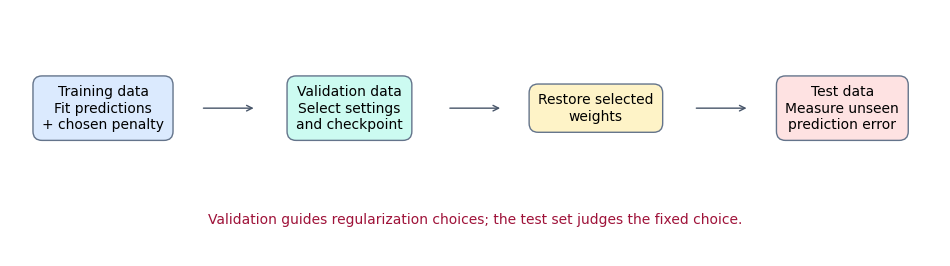

Validation guides regularization choices; the test set judges the fixed choice.

## Distinguish a data error from a preference for simpler weights

The data loss measures prediction errors on examples. A penalty adds a preference about parameters. For L2 regularization with the convention used here,

$$J(\theta)=L_{data}(\theta)+\frac{\lambda}{2}\sum_j w_j^2.$$

$\lambda$ controls how much the penalty matters. Some definitions omit the half; then the derivative has a factor of two. Always check the convention and whether the data loss is summed or averaged. Changing these scales changes the relative strength of the penalty.

The penalty does not directly detect noise. It makes large weights expensive, which can discourage overly sensitive responses in some models. Weight magnitude is not a complete measure of neural-network complexity, especially when layers can rescale each other or normalization is present. Too strong a penalty can suppress the signal we need to learn.

## Calculate every part of one L2 update

Use one neuron $\hat y=wx+b$ with input $x=2$, target $y=1$, initial $w=1$, $b=0$, and half squared error. Prediction is $1(2)+0=2$, error is one, and data loss is $\tfrac12(2-1)^2=0.5$.

Set $\lambda=0.2$ and penalize only the weight. The penalty is $(0.2/2)(1^2)=0.1$, giving total objective $J=0.5+0.1=0.6$.

The data-loss derivative for $w$ is error times input: $(2-1)(2)=2$. The penalty derivative is $\lambda w=0.2(1)=0.2$. Total weight derivative is $2.2$. The unpenalized bias derivative is the error, one.

At SGD rate $0.1$, $w'=1-0.1(2.2)=0.78$ and $b'=0-0.1(1)=-0.1$. The next prediction is $0.78(2)-0.1=1.46$. New data loss is $\tfrac12(0.46)^2=0.1058$; new penalty is $0.1(0.78^2)=0.06084$; total objective is $0.16664$.

This illustrates how the data signal and parameter preference combine. It is not evidence of improved generalization because there is only one example. The larger experiment will report unpenalized validation and test MSE so we can judge prediction quality separately from the penalty.

## Compare L1, L2, and decoupled weight decay

An L1 penalty is $\lambda\sum_j|w_j|$. For weights $[2,-0.5,0]$ and $\lambda=0.1$, it equals $0.1(2+0.5+0)=0.25$. Away from zero, its derivatives are $\lambda\operatorname{sign}(w)$, giving $[0.1,-0.1,0]$ under PyTorch's zero subgradient at zero. L1 can favor sparse solutions, but ordinary finite-step gradient updates do not guarantee exact zeros. L2 instead produces a pull proportional to each weight's magnitude.

For plain SGD without momentum, adding $\lambda w$ to the data gradient yields

$$w'=w-\eta(g_{data}+\lambda w)=(1-\eta\lambda)w-\eta g_{data}.$$

This is equivalent to multiplying the old weight by a decay factor and then taking the data-gradient step. With adaptive optimizers, that equivalence does not generally hold.

**Isolate the difference with zero data gradient.** Start $w=2$, learning rate $0.1$, decay $0.2$, and empty optimizer history. Coupled Adam receives gradient $0+0.2(2)=0.4$; on its first step its bias-corrected moments are $0.4$ and $0.16$. Its move is approximately $0.1(0.4)/(\sqrt{0.16}+\epsilon)=0.1$, giving $w'\approx1.9$. AdamW's separate decay gives $(1-0.1(0.2))2=1.96$ and its zero data gradient contributes no adaptive move.

Use either an explicit L2 objective or the intended optimizer decay configuration. Adding both accidentally changes the regularization. Biases and normalization scale/shift parameters are often excluded from decay; whether to exclude them is a deliberate modeling choice.

## Dropout trains with missing intermediate evidence

During training, dropout randomly zeros activations and rescales kept values. With drop probability $p=0.5$, each kept value is divided by $1-p=0.5$. For activations $[1,2,3,4]$ and illustrative keep mask $[1,0,1,0]$, the result is $[2,0,6,0]$.

The expected multiplier is $0.5(0)+0.5(2)=1$, so each activation's expectation is preserved by this operation. This does not imply that the expected prediction of a nonlinear network is unchanged. If a later sum supplies upstream gradients of one, input gradients for this fixed mask are $[2,0,2,0]$.

Dropout can discourage reliance on one exact combination of hidden activations. It is not permanent neuron deletion and has no trainable weights. In evaluation mode, it returns activations unchanged; do not scale them again. Keep dropout off for validation, test, and ordinary deterministic prediction. Its randomness can complicate a direct comparison of training-time loss to evaluation loss, so our experiment measures both curves in evaluation mode after each update.

## Early stopping uses unseen examples to limit fitting

Early stopping ends training when a validation metric stops improving for a chosen patience. It differs from assuming that the final weights are best. Save a deep copy of the best state and restore it after stopping.

For illustrative validation losses `[0.80, 0.60, 0.50, 0.51, 0.52]`, epoch three has the lowest loss. With patience two and improvement defined as any strict decrease, epoch four is the first non-improvement and epoch five is the second: stop after epoch five and restore epoch three.

Patience counts validation checks, not individual minibatch updates unless you validate after every update. A minimum-improvement threshold can avoid resetting patience for tiny changes; this lesson uses zero so the checkpoint rule stays exact. Validation is part of model selection, so it is not an unbiased final test. The test set remains reserved until method and checkpoint choices are fixed.

## Augmentation should preserve the answer we want

Data augmentation changes a training input while preserving the intended target. It exposes the model to variations we expect at prediction time. The transformation is a modeling assumption: it must be valid for the label, not merely easy to code.

For a synthetic vertical-versus-horizontal bar task, a small translation that keeps the whole bar inside the image preserves orientation. A 90-degree rotation changes a vertical bar into a horizontal one, so keeping the original orientation label would be wrong. For digit recognition, some rotations and flips can similarly change meaning.

Apply random augmentation to training examples only. Validation and test use the specified evaluation preprocessing, unless a separately defined test-time procedure is deliberately being evaluated. Augmented copies of an image must stay with their original training group; creating copies before splitting can leak nearly identical content into evaluation.

## Check whether a transformation preserves the label

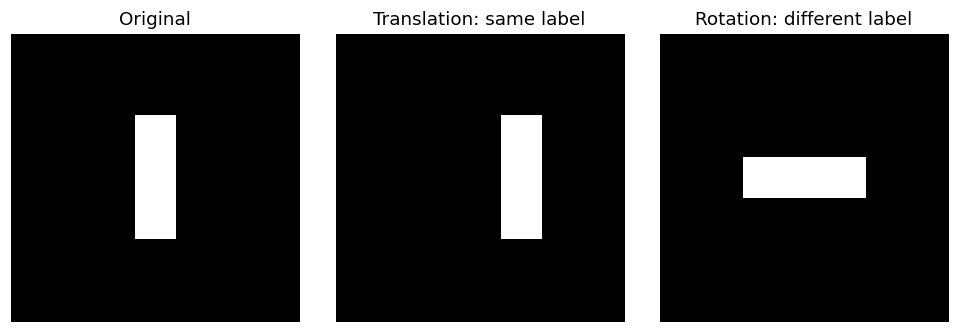

Translation keeps this synthetic bar vertical; a quarter turn makes it horizontal.

## Compare three networks on separate noisy measurements

The underlying signal is `sin(3x) + 0.3x`, with Gaussian observation noise. We generate 20 training readings and independent validation and test groups of 128 each. The known clean rule is used only to explain the synthetic world and draw a reference curve, not to supply training targets without noise.

All methods use the same 1 → 32 → 32 → 1 tanh network, the same initial weights, and Adam at rate 0.01. Compare no explicit penalty, an L2 penalty of `0.001 / 2 × sum(weight²)` excluding biases, and dropout with probability 0.15 after each hidden activation. The methods are fixed in advance; there is no test-driven tuning.

Each method has a maximum of 800 full-batch updates and patience 80 validation checks. Early stopping is shared by all methods, including the unpenalized baseline. Consequently “No explicit penalty” is not a model without any regularizing choices. We record data-only training and validation MSE after every update in evaluation mode, keep the best validation state, and select a final method by validation loss before evaluating test data.

## Compare data errors during training

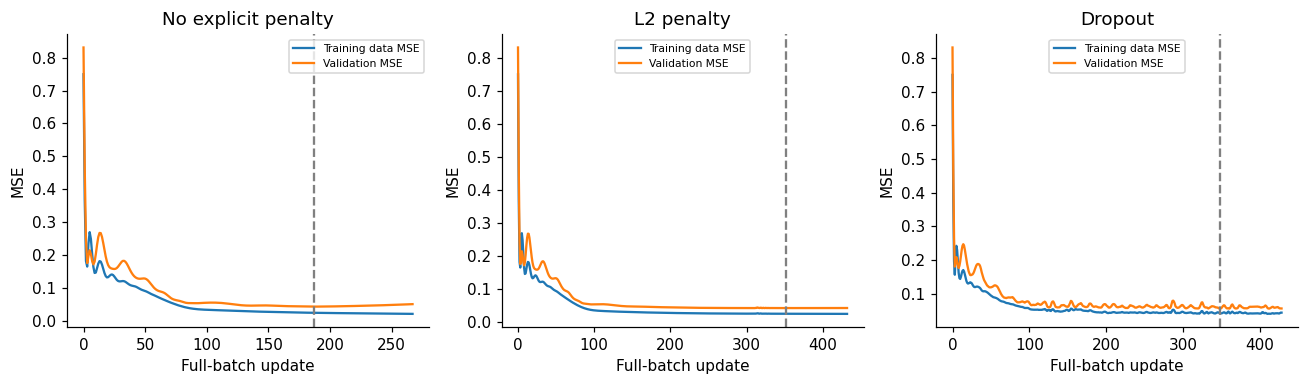

All curves show unpenalized MSE in evaluation mode. The vertical line marks the best validation checkpoint; every method uses the same early-stopping rule.

## Read held-out errors without assuming a winner

Evaluate each predeclared, validation-selected checkpoint on the same test readings. Report ordinary MSE without adding a weight penalty. This compares prediction error in the same units for all methods. The method to keep was already selected using validation; test scores do not change that choice.

A constant baseline predicts the training-target mean. It provides context for whether the networks learned useful structure at all. The plot overlays each fixed prediction curve with test readings and the known synthetic signal. Differences on one small random split may not persist across datasets or seeds.

If regularization reduces both training fit and validation quality, it may be too strong or unsuitable. If a regularized method wins here, that does not establish the chosen coefficient or dropout probability as a default for other problems. The controls isolate a small comparison while keeping early stopping common to all methods.

## Inspect fixed predictions on separate examples

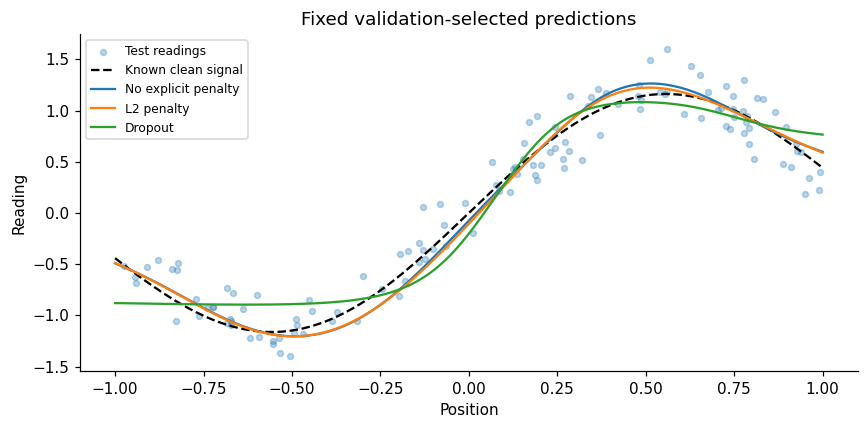

The model choices were fixed before evaluating these test readings. The clean signal is known only because the data-generating process is synthetic.

## Connect each remedy to its mechanism

L1 and L2 change the training objective. Decoupled weight decay changes the parameter update separately from adaptive gradient scaling. Dropout randomly removes intermediate evidence during training. Early stopping limits continued fitting using validation evidence. Valid augmentation changes what variations the model sees while preserving the intended answer.

None repairs wrong labels, leakage, broken preprocessing, or an architecture that cannot represent the required pattern. Start with a working baseline, diagnose the error pattern, and evaluate deliberate changes. Batch normalization primarily concerns optimization and activation behavior; any regularizing effect it introduces is not a substitute for this reasoning.

The hand calculations show exactly how the mechanisms act. The small experiment asks whether those actions help unseen predictions under one controlled setup. Keep the distinction between the mechanism and its empirical benefit.

## Read the saved reference run

All 8 code cells and embedded assertions passed in a fresh in-process CPU kernel. Validation selected **L2 penalty** before the test comparison.

| Method | Best epoch | Stopped after | Validation MSE | Test MSE |
| --- | --- | --- | --- | --- |
| No explicit penalty | 187 | 267 | 0.042498 | 0.043439 |
| L2 penalty | 352 | 432 | 0.041488 | 0.044429 |
| Dropout | 348 | 428 | 0.055587 | 0.068426 |

The training-mean baseline had test MSE 0.738282. All model scores exclude penalty terms. Each model used the same initial weights and early-stopping rule; the coefficients were fixed rather than tuned on test data. These single-split results do not establish a universally best regularizer. The L1/L2, Adam-versus-AdamW, dropout, early-stopping, and augmentation calculations also passed.

Here L2 had the lowest validation MSE, while the model with no explicit penalty had slightly lower test MSE. We keep the validation-selected choice rather than switching after seeing test results. A small validation sample gives an imperfect estimate of future performance. Dropout did worse under this fixed setting; the experiment does not establish whether another strength or training schedule would help.